# Ablation study for Section 5.6 — Guided RL for Omnidirectional 3D Jumping

This notebook is organised around the three claims the paper needs to support, not around a generic
policy comparison. Each claim gets its own section, its own figure, and a sentence with the numbers
filled in.

| # | Ablation | Claim to support | Where |
|---|---|---|---|
| 1 | `no_uarm` | Without the UARM extension the **feasible/reachable region shrinks** and the landing error grows, because the robot hits the ground while charging for longer jumps | §6 |
| 2 | `no_liftoof_disc_penalty` | Without the lift-off penalty the achieved lift-off state **departs from the commanded one**, so the ballistic prediction of Section 5.2 — the apex check and the landing-point prediction — **is no longer valid**. This attacks the paper's predictability/explainability contribution, so it needs the strongest evidence. | §7 |
| 3 | `no_bounce_angular_touchdown` | Without the touchdown penalties the **bounce grows**, producing landing conditions that have to be avoided | §8 |

Claim 4 (enlarged action bounds diverging) is a training-curve result, not an evaluation result — it
belongs with the reward-convergence figure, not here.

**Targets are sampled randomly and independently per run**, so nothing can be paired sample by
sample. Every comparison below is made over a shared partition of the command space: policies are
compared cell by cell, aggregates are stratified over cells, and confidence intervals come from a
cluster bootstrap over cells.

## 1. Setup

In [20]:
import os
import os.path as osp
import warnings
from itertools import product

import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 500, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
    "legend.frameon": False,
})

G = 9.81      # gravity [m/s^2], used by the ballistic model of Section 5.2

In [21]:
robot = "go1"

cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../../../logs/rsl_rl/unitree_{robot}_jump/ablation"))
# data_path = "/absolute/path/to/ablation"      # <-- override if the relative path is wrong

print("data path :", data_path, "| exists:", osp.isdir(data_path))

FIG_DIR = osp.join(data_path, "figures_ablation")
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE = "baseline"
EXPERIMENTS = {
    "baseline":                    ("Baseline",  "Full reward set"),
    "no_uarm":                     ("w/o UARM",  "No UARM extension of the Bezier thrust"),
    "no_liftoof_disc_penalty":     ("w/o LO",    "No lift-off state penalty"),
    "no_bounce_angular_touchdown": ("w/o TD",    "No touchdown bounce / angular-velocity penalty"),
}
COLORS = {
    "baseline":                    "#2c3e50",
    "no_uarm":                     "#c0392b",
    "no_liftoof_disc_penalty":     "#2980b9",
    "no_bounce_angular_touchdown": "#e67e22",
}
ABLATIONS = [k for k in EXPERIMENTS if k != BASELINE]

ERR_ACCEPT = 0.20     # [m] the paper's acceptability threshold (Fig. 10 feasible region)
ERR_TIGHT  = 0.10     # [m]
PEN_CAP    = 0.50     # [m] censoring cap for the selection-free error metric
START_Z    = 0.0      # subtract from the desired z if targets are logged in world coords (e.g. 0.5)
SAVE_FIGS  = True


def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(FIG_DIR, f"{name}.{ext}"), bbox_inches="tight")

data path : /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation | exists: True


## 2. Loading

Two things the loader looks for beyond the obvious:

* **A bounce sentinel.** Section 4.3 says the bounce cost is *set to a high default value when no
  valid touchdown is detected*. If that sentinel made it into `bounce_err.bin`, it is a failure flag
  wearing a distance's clothing and it will wreck the bounce statistics. The loader detects any
  value repeated suspiciously often and reports it.
* **Full lift-off states.** If `lo_pos_err.bin` / `lo_vel_err.bin` store a `[desired, actual]` pair
  (like `pos_err.bin` does) rather than a pre-differenced error, the notebook can run the *exact*
  ballistic analysis that Claim 2 needs. If they store only errors, §7 falls back to a first-order
  bound and tells you so.

In [22]:
def _np(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def _load(path):
    if not osp.isfile(path):
        return None
    o = joblib.load(path)
    return [_np(a) for a in o] if isinstance(o, (list, tuple)) else _np(o)


def _is_pair(raw):
    # True if raw is a [desired, actual] pair of equally shaped arrays
    return (isinstance(raw, (list, tuple)) and len(raw) == 2
            and np.shape(raw[0]) == np.shape(raw[1]) and np.ndim(raw[0]) == 2)


def _as_error(raw):
    if raw is None:
        return None
    if _is_pair(raw):
        return np.asarray(raw[1], float) - np.asarray(raw[0], float)
    if isinstance(raw, (list, tuple)):
        return np.asarray(raw, float)
    return np.asarray(raw, float)


def _mag(err, deg=False):
    if err is None:
        return None
    e = np.asarray(err, float)
    if e.ndim == 0:
        return None
    m = np.abs(e) if e.ndim == 1 else np.linalg.norm(e.reshape(len(e), -1), axis=1)
    return np.degrees(m) if deg else m


def detect_sentinel(v, frac=0.01):
    # a single value repeated in more than `frac` of samples and sitting in the upper tail
    if v is None or len(v) == 0:
        return None
    vals, counts = np.unique(np.round(np.asarray(v, float), 6), return_counts=True)
    hi = np.percentile(v, 75)
    cand = [(c, x) for x, c in zip(vals, counts) if c > frac * len(v) and x >= hi]
    return max(cand)[1] if cand else None


def styled_boxplot(ax, data, labels, colors, **kw):
    kwargs = dict(showfliers=False, patch_artist=True,
                  medianprops=dict(color="black", lw=1.4))
    kwargs.update(kw)
    try:
        bp = ax.boxplot(data, tick_labels=labels, **kwargs)
    except TypeError:
        bp = ax.boxplot(data, labels=labels, **kwargs)
    for p, c in zip(bp["boxes"], colors):
        p.set_facecolor(c)
        p.set_alpha(0.55)
    return bp


def ecdf(ax, v, w=None, **kw):
    v = np.asarray(v, float)
    o = np.argsort(v)
    v = v[o]
    w = np.ones_like(v) if w is None else np.asarray(w, float)[o]
    ax.step(v, np.cumsum(w) / w.sum(), where="post", **kw)


def as_markdown(df, floatfmt=".3f"):
    try:
        return df.to_markdown(index=False, floatfmt=floatfmt)
    except ImportError:
        return df.to_string(index=False)

In [23]:
class DataExp:
    FILES = {
        "pos":        "pos_err.bin",
        "orient_err": "orient_err.bin",
        "fail":       "failed.bin",
        "bounce":     "bounce_err.bin",
        "lo_pos":     "lo_pos_err.bin",
        "lo_orient":  "lo_orient_err.bin",
        "lo_vel":     "lo_vel_err.bin",
        "lo_ang_vel": "lo_ang_vel_err.bin",
        # optional, only used if present -- see the note at the end of section 7
        "td_ang_vel": "td_ang_vel.bin",
        "apex":       "apex.bin",
    }

    def __init__(self, data_path, name):
        self.name = name
        self.exp_path = osp.join(data_path, name)
        self.label, self.long_label = EXPERIMENTS.get(name, (name, name))
        self.color = COLORS.get(name, "#555")

    def load(self):
        self.raw = {k: _load(osp.join(self.exp_path, f)) for k, f in self.FILES.items()}
        return self

    def shapes(self):
        rows = []
        for k, v in self.raw.items():
            if v is None:
                rows.append((self.name, k, "-", "MISSING"))
            elif isinstance(v, list):
                rows.append((self.name, k, f"pair[{len(v)}]",
                             " | ".join(str(np.shape(a)) for a in v)))
            else:
                rows.append((self.name, k, str(v.dtype), str(v.shape)))
        return pd.DataFrame(rows, columns=["exp", "field", "kind", "shape"])

    def process(self):
        des = np.asarray(self.raw["pos"][0], float)
        act = np.asarray(self.raw["pos"][1], float)
        self.n = len(des)

        self.des_pos    = des[:, :2]
        self.actual_pos = act[:, :2]
        self.des_z_abs  = des[:, 2] if des.shape[1] > 2 else np.full(self.n, np.nan)
        self.des_z      = des[:, 2] - START_Z if des.shape[1] > 2 else np.zeros(self.n)
        self.act_z      = act[:, 2] - START_Z if act.shape[1] > 2 else np.zeros(self.n)
        self.land_z_abs = act[:, 2] if act.shape[1] > 2 else None

        self.pos_err = np.linalg.norm(self.des_pos - self.actual_pos, axis=1)

        f = self.raw["fail"]
        self.fail = np.zeros(self.n, bool) if f is None else np.asarray(f).reshape(-1).astype(bool)
        self.ok = ~self.fail

        self.pos_err_pen = np.where(self.fail, PEN_CAP, np.minimum(self.pos_err, PEN_CAP))
        self.accept = self.ok & (self.pos_err <= ERR_ACCEPT)      # paper's Fig. 10 criterion
        self.accept_tight = self.ok & (self.pos_err <= ERR_TIGHT)

        oe = _as_error(self.raw["orient_err"])
        self.yaw_err = (np.degrees(np.abs(oe[:, 2])) if (oe is not None and oe.ndim == 2
                                                         and oe.shape[1] >= 3)
                        else _mag(oe, deg=True))

        # --- bounce, with sentinel detection
        self.bounce = _mag(_as_error(self.raw["bounce"]))
        self.bounce_sentinel = detect_sentinel(self.bounce) if self.bounce is not None else None
        self.bounce_valid = (np.ones(self.n, bool) if self.bounce is None
                             else ~np.isclose(self.bounce, self.bounce_sentinel)
                             if self.bounce_sentinel is not None else np.ones(self.n, bool))

        # --- lift-off: keep full states when the file is a [desired, actual] pair
        self.lo_state = {}
        for key in ("lo_pos", "lo_vel", "lo_orient", "lo_ang_vel"):
            if _is_pair(self.raw[key]):
                self.lo_state[key] = (np.asarray(self.raw[key][0], float),
                                      np.asarray(self.raw[key][1], float))
        self.has_lo_state = ("lo_pos" in self.lo_state) and ("lo_vel" in self.lo_state)

        self.lo_pos     = _mag(_as_error(self.raw["lo_pos"]))
        self.lo_orient  = _mag(_as_error(self.raw["lo_orient"]), deg=True)
        self.lo_vel     = _mag(_as_error(self.raw["lo_vel"]))
        self.lo_ang_vel = _mag(_as_error(self.raw["lo_ang_vel"]))
        self.td_ang_vel = _mag(_as_error(self.raw["td_ang_vel"]))

        self.des_dist    = np.linalg.norm(self.des_pos, axis=1)
        self.actual_dist = np.linalg.norm(self.actual_pos, axis=1)
        self.des_angle   = np.arctan2(self.des_pos[:, 1], self.des_pos[:, 0])
        self.is_front    = self.des_pos[:, 0] >= 0
        return self


METRICS = {
    "pos_err_pen": ("Landing error (censored)", "m",     False),
    "pos_err":     ("Landing error | success",  "m",     True),
    "fail":        ("Failure rate",             "%",     False),
    "accept":      (f"Acceptable @ {ERR_ACCEPT} m", "%", False),
    "accept_tight": (f"Acceptable @ {ERR_TIGHT} m", "%", False),
    "yaw_err":     ("Yaw error",                "deg",   True),
    "bounce":      ("Bounce",                   "m",     True),
    "lo_pos":      ("Lift-off position error",  "m",     True),
    "lo_orient":   ("Lift-off orientation err", "deg",   True),
    "lo_vel":      ("Lift-off lin. vel. error", "m/s",   True),
    "lo_ang_vel":  ("Lift-off ang. vel. error", "rad/s", True),
    "td_ang_vel":  ("Touchdown ang. vel.",      "rad/s", True),
}
PCT = {"fail", "accept", "accept_tight"}
MNAME = {k: v[0] for k, v in METRICS.items()}
MUNIT = {k: v[1] for k, v in METRICS.items()}


def mlabel(k):
    return f"{MNAME.get(k, k)} [{MUNIT.get(k, '-')}]"

In [24]:
exps = {}
for name in EXPERIMENTS:
    e = DataExp(data_path, name)
    if not osp.isdir(e.exp_path):
        print(f"[skip] not found: {e.exp_path}")
        continue
    exps[name] = e.load().process()

base = exps[BASELINE]
abl_present = [n for n in ABLATIONS if n in exps]

print("loaded :", {e.label: e.n for e in exps.values()})
print()
for n, e in exps.items():
    if e.bounce_sentinel is not None:
        k = int(np.isclose(e.bounce, e.bounce_sentinel).sum())
        print(f"[{e.label}] bounce sentinel {e.bounce_sentinel:.4f} in {k} samples "
              f"({100*k/e.n:.1f}%) -> excluded from bounce statistics (invalid touchdown)")
print()
print("full lift-off states available:", {e.label: e.has_lo_state for e in exps.values()})

pd.concat([e.shapes() for e in exps.values()], ignore_index=True) \
  .pivot(index="field", columns="exp", values="shape")

loaded : {'Baseline': 4096, 'w/o UARM': 4096, 'w/o LO': 4096, 'w/o TD': 4096}


full lift-off states available: {'Baseline': False, 'w/o UARM': False, 'w/o LO': False, 'w/o TD': False}


exp,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
field,,,,
apex,MISSING,MISSING,MISSING,MISSING
bounce,"(4096,)","(4096,)","(4096,)","(4096,)"
fail,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_ang_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_orient,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_pos,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
orient_err,"(4096, 3)","(4096, 3)","(4096, 3)","(4096, 3)"
pos,"(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)"


## 3. Shared partition of the command space

Targets are random, so the unit of comparison is a **region**, not a sample. A grid keeps the cell
area exact, which matters in §6 where the feasible region is measured in m².

In [25]:
GRID_NX, GRID_NY = 15, 10
MIN_PER_CELL = 5


class Grid:
    def __init__(self, xy, nx, ny):
        self.xe = np.linspace(xy[:, 0].min(), xy[:, 0].max() + 1e-9, nx + 1)
        self.ye = np.linspace(xy[:, 1].min(), xy[:, 1].max() + 1e-9, ny + 1)
        self.nx, self.ny, self.n_cells = nx, ny, nx * ny
        cx = 0.5 * (self.xe[:-1] + self.xe[1:])
        cy = 0.5 * (self.ye[:-1] + self.ye[1:])
        self.centroids = np.array([[cx[i], cy[j]] for i, j in product(range(nx), range(ny))])
        self.cell_area = (self.xe[1] - self.xe[0]) * (self.ye[1] - self.ye[0])

    def assign(self, xy):
        ix = np.clip(np.digitize(xy[:, 0], self.xe) - 1, 0, self.nx - 1)
        iy = np.clip(np.digitize(xy[:, 1], self.ye) - 1, 0, self.ny - 1)
        return (ix * self.ny + iy).astype(int)

    def plot(self, ax, values, **kw):
        g = np.full((self.nx, self.ny), np.nan)
        for c in range(self.n_cells):
            g[c // self.ny, c % self.ny] = values[c]
        return ax.pcolormesh(self.xe, self.ye, g.T, shading="flat", **kw)


part = Grid(np.vstack([e.des_pos for e in exps.values()]), GRID_NX, GRID_NY)
for e in exps.values():
    e.cell = part.assign(e.des_pos)

counts = pd.DataFrame({e.label: np.bincount(e.cell, minlength=part.n_cells) for e in exps.values()})
VALID = (counts >= MIN_PER_CELL).all(axis=1).values
valid_cells = np.nonzero(VALID)[0]

XLIM = (part.xe[0] - 0.03, part.xe[-1] + 0.03)
YLIM = (part.ye[0] - 0.03, part.ye[-1] + 0.03)

print(f"grid {GRID_NX}x{GRID_NY} = {part.n_cells} cells, cell area {part.cell_area:.4f} m^2")
print(f"usable cells: {VALID.sum()}/{part.n_cells}; samples per cell "
      f"min {counts.values.min()}, median {int(np.median(counts.values))}")

grid 15x10 = 150 cells, cell area 0.0144 m^2
usable cells: 150/150; samples per cell min 13, median 27


In [26]:
def cell_values(e, attr, mask_attr=None):
    v = getattr(e, attr, None)
    if v is None:
        return np.full(part.n_cells, np.nan)
    v = np.asarray(v, float)
    restrict = METRICS.get(attr, (None, None, False))[2]
    extra = getattr(e, mask_attr) if mask_attr else np.ones(e.n, bool)
    out = np.full(part.n_cells, np.nan)
    for c in range(part.n_cells):
        m = (e.cell == c) & extra
        if restrict:
            m = m & e.ok
        if m.sum() >= 3:
            out[c] = np.nanmean(v[m])
    return 100.0 * out if attr in PCT else out


CELL = {a: pd.DataFrame({n: cell_values(e, a, "bounce_valid" if a == "bounce" else None)
                         for n, e in exps.items()})
        for a in METRICS}


def strat(attr, policy):
    return float(np.nanmean(CELL[attr].loc[valid_cells, policy]))


def cluster_ci(d, n_boot=5000, alpha=0.05, seed=0):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) < 3:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    s = np.nanmean(d[rng.integers(0, len(d), (n_boot, len(d)))], axis=1)
    return float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


def cell_compare(abl, attr):
    x = CELL[attr].loc[valid_cells, BASELINE].values
    y = CELL[attr].loc[valid_cells, abl].values
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 5:
        return None
    x, y = x[m], y[m]
    d = y - x
    lo, hi = cluster_ci(d)
    try:
        p = stats.wilcoxon(x, y).pvalue if np.any(d != 0) else 1.0
    except ValueError:
        p = 1.0
    return dict(Ablation=exps[abl].label, Metric=mlabel(attr), attr=attr, cells=int(m.sum()),
                baseline=float(x.mean()), ablation=float(y.mean()), diff=float(d.mean()),
                ci_lo=lo, ci_hi=hi,
                rel=float(100 * d.mean() / abs(x.mean())) if x.mean() else np.nan,
                worse=float(100 * np.mean(d > 0)), p=float(p), sig=stars(p))


rows = [r for n in abl_present for a in METRICS
        if (r := cell_compare(n, a)) is not None]
stats_df = pd.DataFrame(rows)


def holm(p):
    p = np.asarray(p, float)
    o = np.argsort(p)
    m, adj, run = len(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(o):
        run = max(run, (m - rank) * p[i])
        adj[i] = min(run, 1.0)
    return adj


stats_df["p_holm"] = holm(stats_df["p"].values)
stats_df["sig"] = [stars(p) for p in stats_df["p_holm"]]
stats_df.to_csv(osp.join(FIG_DIR, "ablation_cell_stats.csv"), index=False)


def S(abl_name, attr, field):
    r = stats_df[(stats_df["Ablation"] == exps[abl_name].label) & (stats_df["attr"] == attr)]
    return np.nan if r.empty else r.iloc[0][field]


summary = pd.DataFrame([{"Policy": e.label, **{mlabel(a): strat(a, n) for a in METRICS}}
                        for n, e in exps.items()])
summary.set_index("Policy").T.round(4)

/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


Policy,Baseline,w/o UARM,w/o LO,w/o TD
Landing error (censored) [m],0.0796,0.0892,0.1017,0.0876
Landing error | success [m],0.0734,0.0773,0.1024,0.0688
Failure rate [%],1.5343,3.0294,0.0000,4.4111
Acceptable @ 0.2 m [%],85.6749,84.4802,80.7469,84.1185
Acceptable @ 0.1 m [%],76.2817,74.4326,69.4236,75.6241
Yaw error [deg],3.7175,2.8169,2.9221,4.5022
Bounce [m],0.1579,0.1598,0.1422,0.1689
Lift-off position error [m],0.0209,0.0170,0.0262,0.0214
Lift-off orientation err [deg],2.2979,2.1423,3.0718,2.7163
Lift-off lin. vel. error [m/s],0.1981,0.2814,0.5010,0.2382


## 4. Claim 1 — the UARM extension enlarges the feasible region

Paper wording to support: *without the UARM the feasible region is much smaller because the robot
hits the ground more easily when charging for longer jumps.*

The feasible region is defined exactly as in Fig. 10: targets whose landing error stays below
**0.2 m**. Because the grid cells have a known area, the region can be reported in **m²** rather
than eyeballed from a scatter plot — a cell counts as feasible if at least 50% of the jumps
commanded into it were acceptable.

Three pieces of evidence, in increasing order of strength: the region shrinks; the shrinkage is
concentrated at long range (consistent with the charging/ground-contact mechanism); and the failure
rate at long range rises.

In [27]:
FEAS_CELL_FRAC = 50.0    # a cell is drawn as feasible if >= this % of its jumps are acceptable

TOTAL_AREA = VALID.sum() * part.cell_area          # area of the evaluated command space
feas_mask = {n: (CELL["accept"][n].values >= FEAS_CELL_FRAC) & VALID for n in exps}


def effective_area(n, thr=ERR_ACCEPT):
    # Stratified acceptance rate x evaluated area.
    # A continuous version of the feasible region: unlike counting whole cells it does not
    # saturate, so it still separates policies whose errors all sit on the same side of a
    # coarse cell-level vote.
    acc = np.full(part.n_cells, np.nan)
    e = exps[n]
    good = e.ok & (e.pos_err <= thr)
    for c in valid_cells:
        m = e.cell == c
        if m.sum() >= 3:
            acc[c] = good[m].mean()
    return float(np.nanmean(acc[valid_cells])) * TOTAL_AREA


feas_area = {n: effective_area(n) for n in exps}         # continuous, used for the numbers
feas_area_cell = {n: feas_mask[n].sum() * part.cell_area for n in exps}   # used for the contour


def usable_range(n, thr=ERR_ACCEPT, frac=0.5, nb=14):
    # largest commanded distance at which the acceptance rate still exceeds `frac`
    e = exps[n]
    good = e.ok & (e.pos_err <= thr)
    edges = np.linspace(0, e.des_dist.max(), nb + 1)
    last = 0.0
    for a, b in zip(edges[:-1], edges[1:]):
        m = (e.des_dist >= a) & (e.des_dist < b)
        if m.sum() >= 10 and good[m].mean() >= frac:
            last = b
    return last


rows = []
for n, e in exps.items():
    fm = feas_mask[n]
    rows.append({
        "Policy": e.label,
        "Feasible area [m2]": feas_area[n],
        "vs baseline [%]": 100 * (feas_area[n] - feas_area[BASELINE]) / feas_area[BASELINE],
        "Cell-vote area [m2]": feas_area_cell[n],
        "Usable range [m]": usable_range(n),
        "Max radial reach [m]": (np.linalg.norm(part.centroids[fm], axis=1).max()
                                 if fm.any() else 0.0),
        "Failure rate [%]": strat("fail", n),
        "Landing err [m]": strat("pos_err_pen", n),
    })
feas_df = pd.DataFrame(rows).set_index("Policy")
print(f"evaluated command space: {TOTAL_AREA:.3f} m^2")
feas_df.round(4)

evaluated command space: 2.160 m^2


,Feasible area [m2],vs baseline [%],Cell-vote area [m2],Usable range [m],Max radial reach [m],Failure rate [%],Landing err [m]
Policy,,,,,,,
Baseline,1.8502,0.0000,1.8428,0.9503,1.1539,1.5343,0.0796
w/o UARM,1.8244,-1.3945,1.8140,0.9518,1.0630,3.0294,0.0892
w/o LO,1.7438,-5.7520,1.7565,0.9359,0.9485,0.0000,0.1017
w/o TD,1.8166,-1.8167,1.8284,0.9529,1.0355,4.4111,0.0876


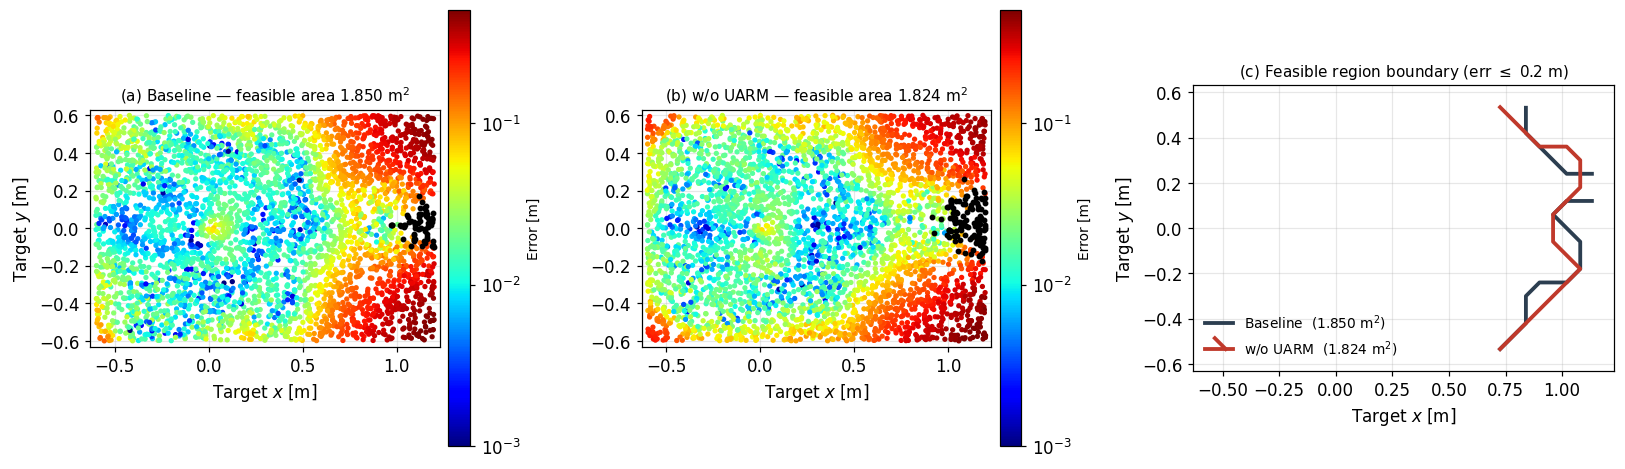

In [28]:
fig = plt.figure(figsize=(15, 4.4))

# (a) paper-style scatter of the two policies that matter for this claim
for i, n in enumerate([BASELINE, "no_uarm"]):
    if n not in exps:
        continue
    ax = fig.add_subplot(1, 3, i + 1)
    e = exps[n]
    ok = e.ok
    sc = ax.scatter(e.des_pos[ok, 0], e.des_pos[ok, 1], s=6, c=e.pos_err[ok],
                    norm=LogNorm(vmin=1e-3, vmax=0.5), cmap="jet", zorder=5)
    ax.scatter(e.des_pos[~ok, 0], e.des_pos[~ok, 1], s=8, color="black", zorder=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_title(f"({chr(97+i)}) {e.label} — feasible area "
                 f"{feas_area[n]:.3f} m$^2$", fontsize=10)
    ax.set_xlabel("Target $x$ [m]")
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label("Error [m]", fontsize=9)
    cb.ax.minorticks_off()

# (c) feasible-region overlay
ax = fig.add_subplot(1, 3, 3)
for n in [BASELINE] + [a for a in ["no_uarm"] if a in exps]:
    m = feas_mask[n].astype(float)
    m[~VALID] = np.nan
    ax.contour(part.centroids[:, 0].reshape(part.nx, part.ny),
               part.centroids[:, 1].reshape(part.nx, part.ny),
               m.reshape(part.nx, part.ny), levels=[0.5],
               colors=[exps[n].color], linewidths=2.5)
    ax.plot([], [], color=exps[n].color, lw=2.5,
            label=f"{exps[n].label}  ({feas_area[n]:.3f} m$^2$)")
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
ax.set_xlabel("Target $x$ [m]"); ax.set_ylabel("Target $y$ [m]")
ax.set_title(f"(c) Feasible region boundary (err $\\leq$ {ERR_ACCEPT} m)", fontsize=10)
ax.legend(fontsize=9, loc="lower left")

fig.tight_layout()
savefig(fig, "claim1_uarm_feasible_region")
plt.show()

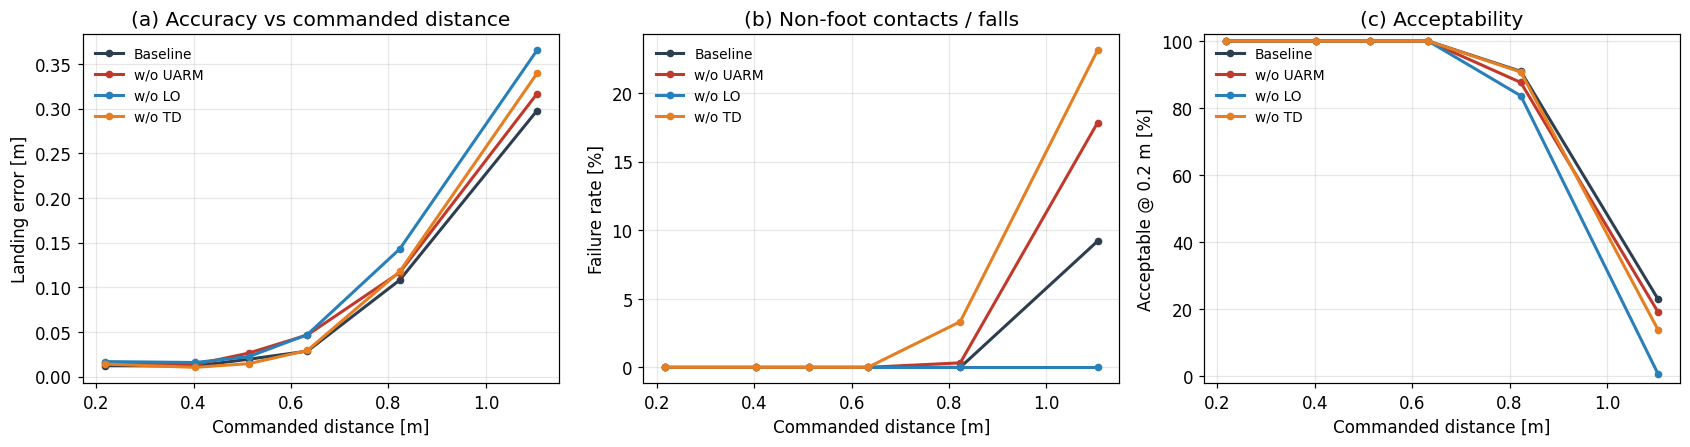

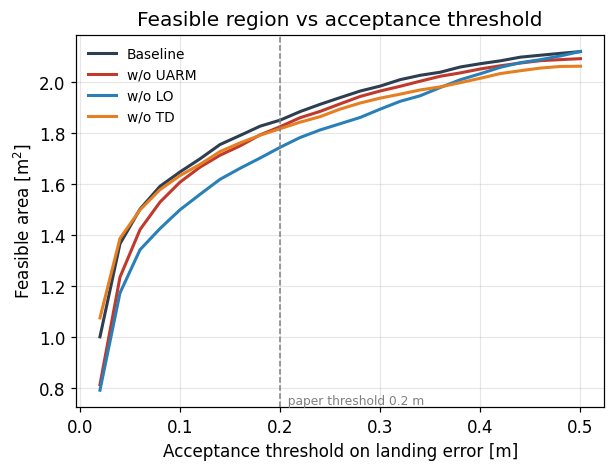

UARM gap vs distance : slope +0.0145 m per m (95% CI [-0.0041, +0.0331]), Spearman rho -0.01, p 8.83e-01
                       near cells +0.0039 m | far cells +0.0151 m


In [29]:
# the mechanism: damage concentrated at long range, and more non-foot contacts there
cdist = np.linalg.norm(part.centroids, axis=1)
r_edges = np.quantile(cdist[valid_cells], np.linspace(0, 1, 7))
r_c = 0.5 * (r_edges[:-1] + r_edges[1:])

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

for n, e in exps.items():
    v = CELL["pos_err_pen"][n].values
    f = CELL["fail"][n].values
    a = CELL["accept"][n].values
    ye, yf, ya = [], [], []
    for lo_, hi_ in zip(r_edges[:-1], r_edges[1:]):
        sel = valid_cells[(cdist[valid_cells] >= lo_) & (cdist[valid_cells] <= hi_)]
        ye.append(np.nanmean(v[sel])); yf.append(np.nanmean(f[sel])); ya.append(np.nanmean(a[sel]))
    axes[0].plot(r_c, ye, "-o", ms=4, lw=2, color=e.color, label=e.label)
    axes[1].plot(r_c, yf, "-o", ms=4, lw=2, color=e.color, label=e.label)
    axes[2].plot(r_c, ya, "-o", ms=4, lw=2, color=e.color, label=e.label)

axes[0].set_ylabel("Landing error [m]"); axes[0].set_title("(a) Accuracy vs commanded distance")
axes[1].set_ylabel("Failure rate [%]");  axes[1].set_title("(b) Non-foot contacts / falls")
axes[2].set_ylabel(f"Acceptable @ {ERR_ACCEPT} m [%]"); axes[2].set_title("(c) Acceptability")
axes[2].set_ylim(-2, 102)
for ax in axes:
    ax.set_xlabel("Commanded distance [m]"); ax.legend(fontsize=9)
fig.tight_layout()
savefig(fig, "claim1_uarm_vs_distance")
plt.show()

# feasible area as a function of the acceptance threshold -- removes the arbitrariness of 0.2 m
thrs = np.linspace(0.02, 0.5, 25)
fig, ax = plt.subplots(figsize=(6.2, 4.4))
for n, e in exps.items():
    ax.plot(thrs, [effective_area(n, t) for t in thrs], lw=2, color=e.color, label=e.label)
ax.axvline(ERR_ACCEPT, color="grey", ls="--", lw=1)
ax.text(ERR_ACCEPT, ax.get_ylim()[0], f"  paper threshold {ERR_ACCEPT} m", fontsize=8,
        va="bottom", color="grey")
ax.set_xlabel("Acceptance threshold on landing error [m]")
ax.set_ylabel("Feasible area [m$^2$]")
ax.set_title("Feasible region vs acceptance threshold")
ax.legend(fontsize=9)
savefig(fig, "claim1_area_vs_threshold")
plt.show()

# formal distance-dependence test for the UARM gap
if "no_uarm" in exps:
    d = (CELL["pos_err_pen"]["no_uarm"].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    lr = stats.linregress(r[m], d[m])
    rho = stats.spearmanr(r[m], d[m])
    near, far = r[m] < np.median(r[m]), r[m] >= np.median(r[m])
    print(f"UARM gap vs distance : slope {lr.slope:+.4f} m per m "
          f"(95% CI [{lr.slope-1.96*lr.stderr:+.4f}, {lr.slope+1.96*lr.stderr:+.4f}]), "
          f"Spearman rho {rho.statistic:+.2f}, p {rho.pvalue:.2e}")
    print(f"                       near cells {d[m][near].mean():+.4f} m | "
          f"far cells {d[m][far].mean():+.4f} m")

## 5. Claim 2 — without the lift-off penalty the ballistic prediction stops being valid

This is the claim that defends the paper's predictability contribution, so it needs more than
"the lift-off error got bigger". The argument has two links:

1. **The achieved lift-off state departs from the commanded one.** Direct from the lift-off errors.
2. **Therefore the Section 5.2 machinery breaks.** The apex check (27) and the landing prediction (1)
   are evaluated on the *commanded* lift-off state — that is the whole point of the safety filter,
   it runs before the jump. If the robot does not realise that state, the filter is predicting a
   jump that will not happen.

If the full lift-off states are available the notebook computes this exactly, decomposing

    |predicted landing (from commanded lift-off) − actual landing|
        ≈ |predicted from commanded − predicted from achieved|      (lift-off tracking)
        + |predicted from achieved − actual landing|                (ballistic model error)

so you can show the *first* term is what blows up. Otherwise it falls back to a first-order bound.

In [30]:
def flight_time(clo_z, vlo_z, z_land):
    # solve z_land = clo_z + vlo_z T - 0.5 g T^2 for the descending root
    disc = vlo_z ** 2 + 2 * G * (clo_z - z_land)
    T = np.where(disc >= 0, (vlo_z + np.sqrt(np.clip(disc, 0, None))) / G, np.nan)
    return T


def apex_height(clo_z, vlo_z):
    return clo_z + vlo_z ** 2 / (2 * G)          # paper eq. (27)


def predict_landing(clo, vlo, z_land):
    T = flight_time(clo[:, 2], vlo[:, 2], z_land)
    return clo[:, :2] + vlo[:, :2] * T[:, None], T


BALLISTIC_MODE = all(e.has_lo_state for e in exps.values())
print("exact ballistic analysis available:", BALLISTIC_MODE)

if BALLISTIC_MODE:
    for n, e in exps.items():
        clo_d, clo_a = e.lo_state["lo_pos"]
        vlo_d, vlo_a = e.lo_state["lo_vel"]
        z_land = e.land_z_abs if e.land_z_abs is not None else np.full(e.n, clo_d[:, 2].mean())

        p_cmd, T_cmd = predict_landing(clo_d, vlo_d, z_land)
        p_act, T_act = predict_landing(clo_a, vlo_a, z_land)

        e.pred_err_filter = np.linalg.norm(p_cmd - e.actual_pos, axis=1)   # what the filter promises
        e.pred_err_model  = np.linalg.norm(p_act - e.actual_pos, axis=1)   # ballistic model error
        e.pred_err_lo     = np.linalg.norm(p_cmd - p_act, axis=1)          # lift-off tracking share
        e.T_fl_cmd, e.T_fl_act = T_cmd, T_act
        e.apex_cmd = apex_height(clo_d[:, 2], vlo_d[:, 2])
        e.apex_act = apex_height(clo_a[:, 2], vlo_a[:, 2])
        e.apex_err = np.abs(e.apex_cmd - e.apex_act)
else:
    print()
    print("Falling back to a first-order bound. To make Claim 2 airtight, dump the lift-off")
    print("states themselves, not just the error magnitudes:")
    print("    joblib.dump([clo_des, clo_act], 'lo_pos_err.bin')")
    print("    joblib.dump([vlo_des, vlo_act], 'lo_vel_err.bin')")
    print("Then re-run: the notebook will compute the exact prediction-error decomposition.")
    T_FL_NOMINAL = 0.45      # [s] rough flight time; set from your data
    for n, e in exps.items():
        lp = e.lo_pos if e.lo_pos is not None else np.zeros(e.n)
        lv = e.lo_vel if e.lo_vel is not None else np.zeros(e.n)
        e.pred_err_lo = lp + T_FL_NOMINAL * lv        # |dc_lo| + T|dv_lo| upper bound
        e.pred_err_filter = np.full(e.n, np.nan)
        e.pred_err_model = np.full(e.n, np.nan)
        e.apex_err = np.full(e.n, np.nan)

for k in ("pred_err_lo", "pred_err_filter", "pred_err_model", "apex_err"):
    METRICS[k] = ({"pred_err_lo": "Lift-off-induced landing pred. error",
                   "pred_err_filter": "Safety-filter landing pred. error",
                   "pred_err_model": "Ballistic model error",
                   "apex_err": "Apex prediction error"}[k], "m", True)
    MNAME[k], MUNIT[k] = METRICS[k][0], METRICS[k][1]
    CELL[k] = pd.DataFrame({n: cell_values(e, k) for n, e in exps.items()})
    for n in abl_present:
        r = cell_compare(n, k)
        if r is not None:
            stats_df.loc[len(stats_df)] = {**r, "p_holm": r["p"]}
print("done")

exact ballistic analysis available: False

Falling back to a first-order bound. To make Claim 2 airtight, dump the lift-off
states themselves, not just the error magnitudes:
    joblib.dump([clo_des, clo_act], 'lo_pos_err.bin')
    joblib.dump([vlo_des, vlo_act], 'lo_vel_err.bin')
Then re-run: the notebook will compute the exact prediction-error decomposition.
done


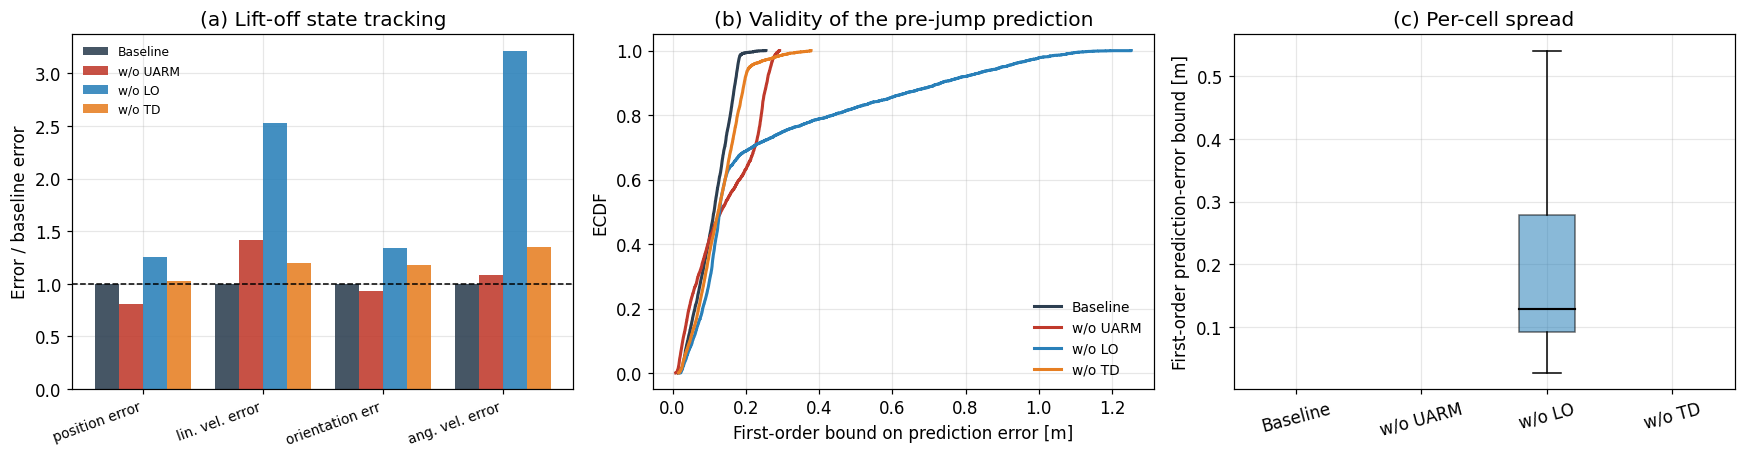

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) lift-off tracking errors -- link 1
ax = axes[0]
lo_attrs = [a for a in ("lo_pos", "lo_vel", "lo_orient", "lo_ang_vel")
            if np.isfinite(CELL[a][BASELINE].values[valid_cells]).any()]
x = np.arange(len(lo_attrs)); w = 0.8 / max(len(exps), 1)
for i, (n, e) in enumerate(exps.items()):
    vals = [strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in lo_attrs]
    ax.bar(x + i * w - 0.4 + w / 2, vals, width=w, color=e.color, alpha=0.88, label=e.label)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels([MNAME[a].replace("Lift-off ", "") for a in lo_attrs],
                                     rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Error / baseline error")
ax.set_title("(a) Lift-off state tracking")
ax.legend(fontsize=8)

# (b) consequence for the prediction -- link 2
ax = axes[1]
for n, e in exps.items():
    v = e.pred_err_filter if BALLISTIC_MODE else e.pred_err_lo
    ecdf(ax, v[np.isfinite(v) & e.ok], color=e.color, lw=2, label=e.label)
ax.set_xlabel("Predicted $-$ actual landing point [m]" if BALLISTIC_MODE
              else "First-order bound on prediction error [m]")
ax.set_ylabel("ECDF")
ax.set_title("(b) Validity of the pre-jump prediction")
ax.legend(fontsize=9)

# (c) decomposition
ax = axes[2]
if BALLISTIC_MODE:
    labs = [e.label for e in exps.values()]
    lo_share = [strat("pred_err_lo", n) for n in exps]
    mod_share = [strat("pred_err_model", n) for n in exps]
    ax.bar(labs, mod_share, color="0.7", label="ballistic model error")
    ax.bar(labs, lo_share, bottom=mod_share, color=[e.color for e in exps.values()],
           alpha=0.9, label="lift-off tracking")
    ax.set_ylabel("Landing prediction error [m]")
    ax.set_title("(c) What breaks the prediction")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=15)
else:
    styled_boxplot(ax, [CELL["pred_err_lo"].loc[valid_cells, n].values for n in exps],
                   [e.label for e in exps.values()], [e.color for e in exps.values()])
    ax.set_ylabel("First-order prediction-error bound [m]")
    ax.set_title("(c) Per-cell spread")
    ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
savefig(fig, "claim2_liftoff_predictability")
plt.show()

In [32]:
# how often would the pre-jump safety filter be wrong?
if BALLISTIC_MODE:
    flat = np.nanstd(base.des_z_abs) < 1e-6
    if flat:
        print("NOTE: all targets are at the same height, so the apex gate of eq. (27) is")
        print("      never binding here. The informative quantities are the apex PREDICTION error")
        print("      and the landing prediction error; the accept/false-accept columns will be")
        print("      trivial. Re-run on the elevated-target set to exercise the gate itself.")
        print()
    rows = []
    for n, e in exps.items():
        passes = e.apex_cmd >= e.des_z_abs            # the pre-jump verdict of eq. (27)
        bad = passes & (~e.accept)
        rows.append({
            "Policy": e.label,
            "Filter accepts [%]": 100 * passes.mean(),
            "False accept [%]": 100 * bad.sum() / max(passes.sum(), 1),
            "Apex pred. error [m]": np.nanmean(e.apex_err),
            "Landing pred. error [m]": np.nanmean(e.pred_err_filter[e.ok]),
            "  of which lift-off [m]": np.nanmean(e.pred_err_lo[e.ok]),
            "  of which model [m]": np.nanmean(e.pred_err_model[e.ok]),
        })
    filt_df = pd.DataFrame(rows).set_index("Policy")
    print("Reliability of the Section 5.2 pre-jump check")
    display(filt_df.round(4))
else:
    print("Skipped: needs the full lift-off states (see the message in the previous cell).")

Skipped: needs the full lift-off states (see the message in the previous cell).


## 6. Claim 3 — without the touchdown penalties the bounce grows

Paper wording to support: the touchdown bounce and angular-velocity penalties suppress rebounces
that the (deliberately absent) landing controller cannot dissipate.

Note the sentinel handling from §2: Section 4.3 sets the bounce cost to a high default when no valid
touchdown is detected, so those samples are counted as **invalid touchdowns** rather than as very
large bounces. Both numbers are reported — the invalid-touchdown rate is itself part of the claim.

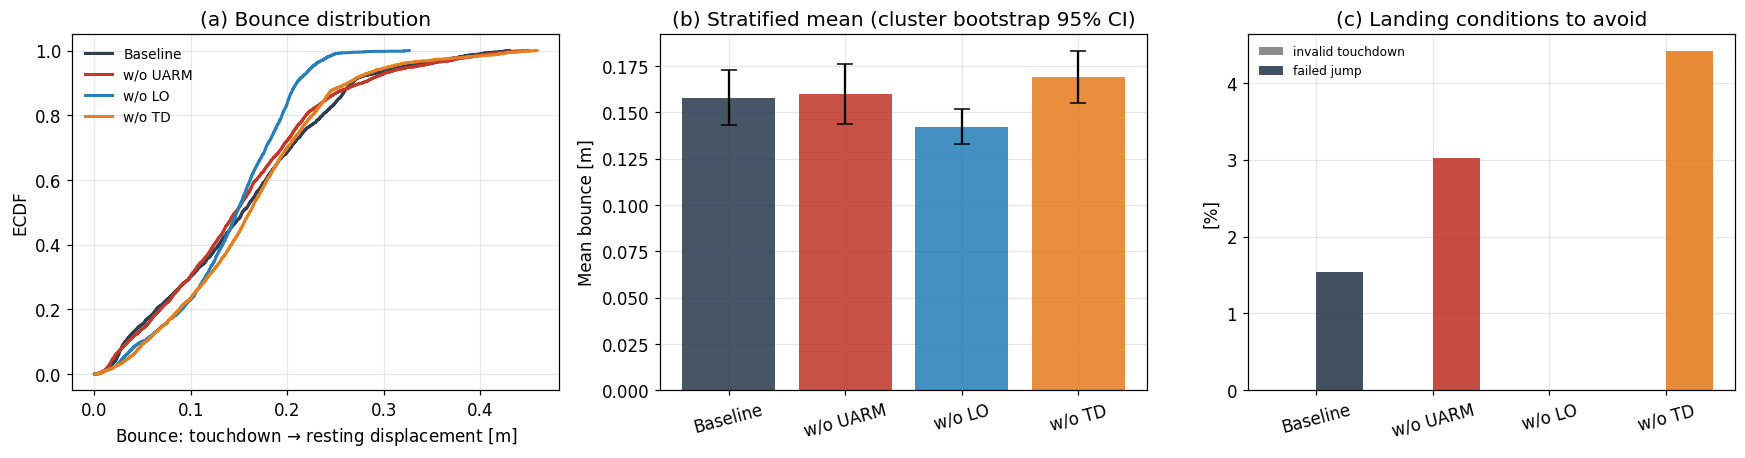

In [33]:
have_b = [n for n, e in exps.items() if e.bounce is not None]

if not have_b:
    print("bounce_err.bin not found — skipping")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

    ax = axes[0]
    for n in have_b:
        e = exps[n]
        m = e.bounce_valid & e.ok
        ecdf(ax, e.bounce[m], color=e.color, lw=2, label=e.label)
    ax.set_xlabel("Bounce: touchdown $\\to$ resting displacement [m]")
    ax.set_ylabel("ECDF"); ax.set_title("(a) Bounce distribution"); ax.legend(fontsize=9)

    ax = axes[1]
    labs, mu, elo, ehi, cols = [], [], [], [], []
    for n in have_b:
        e = exps[n]
        v = CELL["bounce"].loc[valid_cells, n].values
        m_ = np.nanmean(v)
        lo, hi = cluster_ci(v)
        labs.append(e.label); mu.append(m_)
        elo.append(max(m_ - lo, 0)); ehi.append(max(hi - m_, 0)); cols.append(e.color)
    ax.bar(labs, mu, yerr=[elo, ehi], color=cols, alpha=0.88, capsize=5)
    ax.set_ylabel("Mean bounce [m]")
    ax.set_title("(b) Stratified mean (cluster bootstrap 95% CI)")
    ax.tick_params(axis="x", rotation=15)

    ax = axes[2]
    inval = [100 * (~exps[n].bounce_valid).mean() for n in have_b]
    fails = [strat("fail", n) for n in have_b]
    xx = np.arange(len(have_b))
    ax.bar(xx - 0.2, inval, width=0.4, color="0.55", label="invalid touchdown")
    ax.bar(xx + 0.2, fails, width=0.4, color=[exps[n].color for n in have_b],
           alpha=0.9, label="failed jump")
    ax.set_xticks(xx); ax.set_xticklabels([exps[n].label for n in have_b], rotation=15)
    ax.set_ylabel("[%]"); ax.set_title("(c) Landing conditions to avoid"); ax.legend(fontsize=8)

    fig.tight_layout()
    savefig(fig, "claim3_touchdown_bounce")
    plt.show()

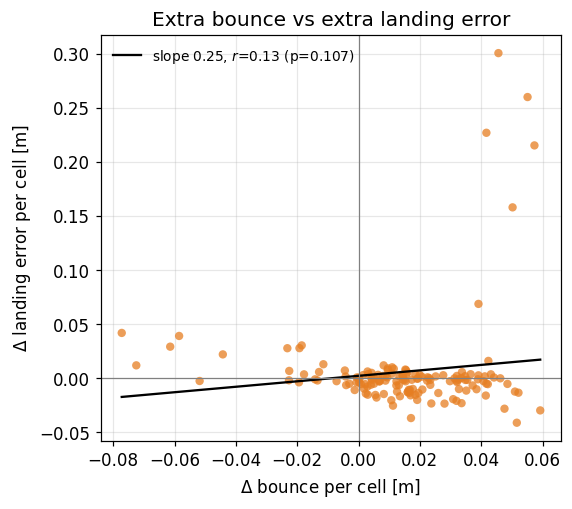

Pearson r = 0.133 (p = 0.1071), Spearman rho = -0.170


In [34]:
# does the extra bounce actually show up as worse landings, cell by cell?
tgt = "no_bounce_angular_touchdown"
if tgt in exps and exps[tgt].bounce is not None:
    db = (CELL["bounce"][tgt].values - CELL["bounce"][BASELINE].values)[valid_cells]
    de = (CELL["pos_err_pen"][tgt].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    m = np.isfinite(db) & np.isfinite(de)
    r, rho = stats.pearsonr(db[m], de[m]), stats.spearmanr(db[m], de[m])

    fig, ax = plt.subplots(figsize=(5.4, 4.8))
    ax.scatter(db[m], de[m], s=30, color=exps[tgt].color, alpha=0.75, edgecolors="none")
    sl, ic = np.polyfit(db[m], de[m], 1)
    xs = np.linspace(db[m].min(), db[m].max(), 10)
    ax.plot(xs, sl * xs + ic, "k-", lw=1.5,
            label=f"slope {sl:.2f}, $r$={r.statistic:.2f} (p={r.pvalue:.3f})")
    ax.axhline(0, color="grey", lw=.8); ax.axvline(0, color="grey", lw=.8)
    ax.set_xlabel("$\\Delta$ bounce per cell [m]")
    ax.set_ylabel("$\\Delta$ landing error per cell [m]")
    ax.set_title("Extra bounce vs extra landing error")
    ax.legend(fontsize=9)
    savefig(fig, "claim3_bounce_mechanism")
    plt.show()
    print(f"Pearson r = {r.statistic:.3f} (p = {r.pvalue:.4f}), "
          f"Spearman rho = {rho.statistic:.3f}")

## 7. Composite figure and paper table

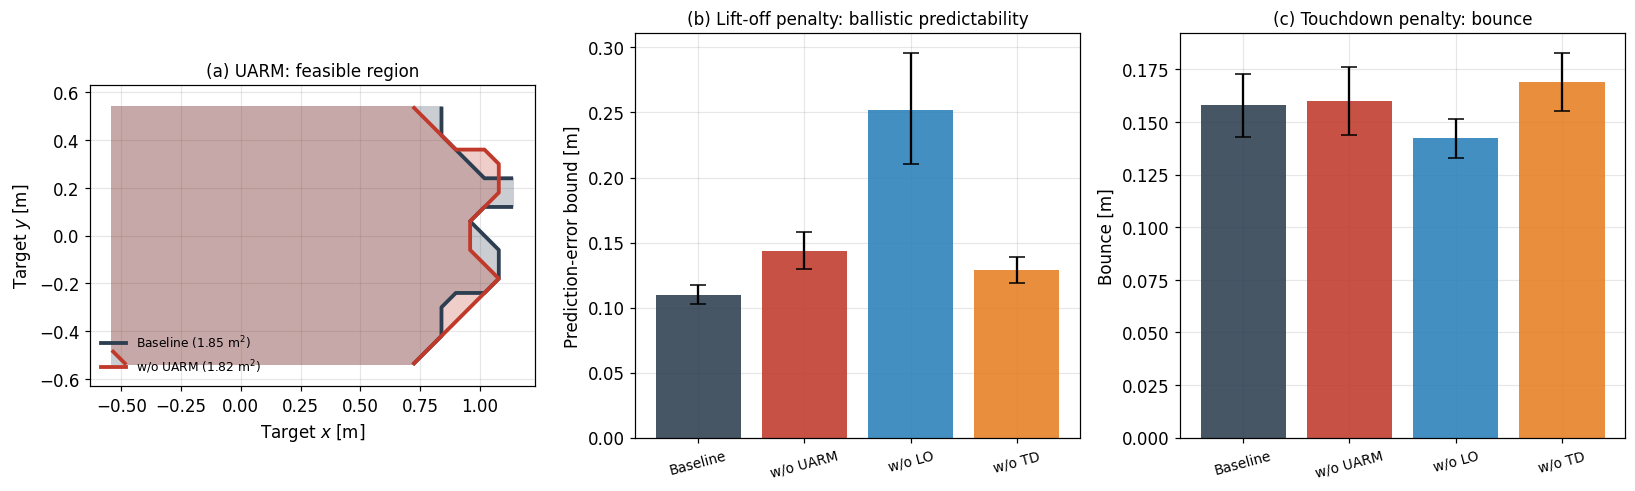

In [35]:
fig = plt.figure(figsize=(15, 4.6))

# (a) claim 1 -- feasible region
ax = fig.add_subplot(1, 3, 1)
for n in [BASELINE] + [a for a in ["no_uarm"] if a in exps]:
    m = feas_mask[n].astype(float)
    ax.contourf(part.centroids[:, 0].reshape(part.nx, part.ny),
                part.centroids[:, 1].reshape(part.nx, part.ny),
                m.reshape(part.nx, part.ny), levels=[0.5, 1.5],
                colors=[exps[n].color], alpha=0.25)
    ax.contour(part.centroids[:, 0].reshape(part.nx, part.ny),
               part.centroids[:, 1].reshape(part.nx, part.ny),
               m.reshape(part.nx, part.ny), levels=[0.5],
               colors=[exps[n].color], linewidths=2.5)
    ax.plot([], [], color=exps[n].color, lw=2.5,
            label=f"{exps[n].label} ({feas_area[n]:.2f} m$^2$)")
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
ax.set_xlabel("Target $x$ [m]"); ax.set_ylabel("Target $y$ [m]")
ax.set_title("(a) UARM: feasible region", fontsize=11)
ax.legend(fontsize=8, loc="lower left")

# (b) claim 2 -- predictability
ax = fig.add_subplot(1, 3, 2)
key = "pred_err_filter" if BALLISTIC_MODE else "pred_err_lo"
labs = [e.label for e in exps.values()]
mu, elo, ehi = [], [], []
for n in exps:
    v = CELL[key].loc[valid_cells, n].values
    m_ = np.nanmean(v)
    lo, hi = cluster_ci(v)
    mu.append(m_); elo.append(max(m_ - lo, 0)); ehi.append(max(hi - m_, 0))
ax.bar(labs, mu, yerr=[elo, ehi], color=[e.color for e in exps.values()], alpha=0.88, capsize=5)
ax.set_ylabel("Landing prediction error [m]" if BALLISTIC_MODE
              else "Prediction-error bound [m]")
ax.set_title("(b) Lift-off penalty: ballistic predictability", fontsize=11)
ax.tick_params(axis="x", rotation=15, labelsize=9)

# (c) claim 3 -- bounce
ax = fig.add_subplot(1, 3, 3)
mu, elo, ehi = [], [], []
for n in exps:
    v = CELL["bounce"].loc[valid_cells, n].values
    m_ = np.nanmean(v)
    lo, hi = cluster_ci(v)
    mu.append(m_); elo.append(max(m_ - lo, 0)); ehi.append(max(hi - m_, 0))
ax.bar(labs, mu, yerr=[elo, ehi], color=[e.color for e in exps.values()], alpha=0.88, capsize=5)
ax.set_ylabel("Bounce [m]")
ax.set_title("(c) Touchdown penalty: bounce", fontsize=11)
ax.tick_params(axis="x", rotation=15, labelsize=9)

fig.tight_layout()
savefig(fig, "ablation_paper_figure")
plt.show()

In [36]:
paper_rows = []
for n, e in exps.items():
    paper_rows.append({
        "Policy": e.label,
        "Feas. area [m$^2$]": feas_area[n],
        "Max reach [m]": feas_df.loc[e.label, "Max radial reach [m]"],
        "Landing err [m]": strat("pos_err_pen", n),
        "Failures [\\%]": strat("fail", n),
        "LO vel. err [m/s]": strat("lo_vel", n),
        "Pred. err [m]": strat("pred_err_filter" if BALLISTIC_MODE else "pred_err_lo", n),
        "Bounce [m]": strat("bounce", n),
    })
paper_tbl = pd.DataFrame(paper_rows)
tex = paper_tbl.to_latex(index=False, float_format="%.3f", escape=False)
with open(osp.join(FIG_DIR, "ablation_table.tex"), "w") as fh:
    fh.write(tex)
print(tex)
paper_tbl.round(4)

\begin{tabular}{lrrrrrrr}
\toprule
Policy & Feas. area [m$^2$] & Max reach [m] & Landing err [m] & Failures [\%] & LO vel. err [m/s] & Pred. err [m] & Bounce [m] \\
\midrule
Baseline & 1.850 & 1.154 & 0.080 & 1.534 & 0.198 & 0.110 & 0.158 \\
w/o UARM & 1.824 & 1.063 & 0.089 & 3.029 & 0.281 & 0.144 & 0.160 \\
w/o LO & 1.744 & 0.948 & 0.102 & 0.000 & 0.501 & 0.252 & 0.142 \\
w/o TD & 1.817 & 1.036 & 0.088 & 4.411 & 0.238 & 0.129 & 0.169 \\
\bottomrule
\end{tabular}



,Policy,Feas. area [m$^2$],Max reach [m],Landing err [m],Failures [\%],LO vel. err [m/s],Pred. err [m],Bounce [m]
0,Baseline,1.8502,1.1539,0.0796,1.5343,0.1981,0.1101,0.1579
1,w/o UARM,1.8244,1.0630,0.0892,3.0294,0.2814,0.1436,0.1598
2,w/o LO,1.7438,0.9485,0.1017,0.0000,0.5010,0.2517,0.1422
3,w/o TD,1.8166,1.0355,0.0876,4.4111,0.2382,0.1286,0.1689


## 8. Draft text for Section 5.6

Numbers are pulled from the analysis above. Read it before pasting — it states what the data shows,
which may not be what you hoped it would show.

In [37]:
def fp(p):
    return "< 0.001" if p < 1e-3 else f"= {p:.3f}"


L = ["# Section 5.6 — Ablation study (auto-generated draft)", ""]
L.append(f"Setup: each policy evaluated on an independently sampled random target set "
         f"({', '.join(f'{e.label}: {e.n}' for e in exps.values())} jumps). Because the target sets "
         f"differ, policies are compared over a shared {GRID_NX}x{GRID_NY} partition of the command "
         f"space ({int(VALID.sum())} usable cells); aggregates are stratified over cells and "
         f"confidence intervals are cluster bootstraps over cells.")
L.append("")
L.append(as_markdown(paper_tbl))
L.append("")

# --- claim 1
if "no_uarm" in exps:
    a = feas_area["no_uarm"]; b = feas_area[BASELINE]
    L.append("## UARM extension")
    L.append("")
    L.append(f"Removing the UARM segment shrinks the feasible region (targets with landing error "
             f"below {ERR_ACCEPT} m) from **{b:.3f} m2 to {a:.3f} m2**, a reduction of "
             f"**{100*(b-a)/b:.1f}%**. The maximum radial reach drops from "
             f"{feas_df.loc[exps[BASELINE].label,'Max radial reach [m]']:.2f} m to "
             f"{feas_df.loc[exps['no_uarm'].label,'Max radial reach [m]']:.2f} m. "
             f"The stratified landing error rises from {strat('pos_err_pen', BASELINE):.3f} m to "
             f"{strat('pos_err_pen','no_uarm'):.3f} m "
             f"({S('no_uarm','pos_err_pen','rel'):+.1f}%, p {fp(S('no_uarm','pos_err_pen','p_holm'))}), "
             f"and the failure rate from {strat('fail', BASELINE):.2f}% to "
             f"{strat('fail','no_uarm'):.2f}%.")
    d = (CELL["pos_err_pen"]["no_uarm"].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    rho = stats.spearmanr(r[m], d[m])
    near, far = r[m] < np.median(r[m]), r[m] >= np.median(r[m])
    L.append(f"Consistent with the proposed mechanism, the degradation is concentrated at long "
             f"range: the gap is {d[m][near].mean():+.3f} m on near cells versus "
             f"{d[m][far].mean():+.3f} m on far cells (Spearman rho {rho.statistic:+.2f} between "
             f"commanded distance and the gap, p {fp(rho.pvalue)}), i.e. the trajectory can no "
             f"longer charge for long jumps without violating the minimum-height constraint.")
    L.append("")

# --- claim 2
if "no_liftoof_disc_penalty" in exps:
    n = "no_liftoof_disc_penalty"
    L.append("## Lift-off state penalty")
    L.append("")
    parts = []
    for a in ("lo_pos", "lo_vel", "lo_orient", "lo_ang_vel"):
        if np.isfinite(S(n, a, "rel")):
            parts.append(f"{MNAME[a].lower()} {S(n,a,'rel'):+.0f}%")
    L.append(f"Removing the lift-off penalty degrades the tracking of the commanded lift-off state "
             f"({'; '.join(parts)}).")
    if BALLISTIC_MODE:
        L.append(f"The consequence is that the ballistic prediction of Section 5.2, which is "
                 f"evaluated on the *commanded* lift-off state before the jump is executed, no "
                 f"longer describes the motion that actually occurs: the distance between the "
                 f"predicted and the realised landing point grows from "
                 f"{strat('pred_err_filter', BASELINE):.3f} m to "
                 f"{strat('pred_err_filter', n):.3f} m "
                 f"({S(n,'pred_err_filter','rel'):+.0f}%, p {fp(S(n,'pred_err_filter','p_holm'))}). "
                 f"Decomposing this error, the lift-off tracking term rises from "
                 f"{strat('pred_err_lo', BASELINE):.3f} m to {strat('pred_err_lo', n):.3f} m while "
                 f"the ballistic model term stays at "
                 f"{strat('pred_err_model', BASELINE):.3f} / {strat('pred_err_model', n):.3f} m, "
                 f"confirming that the loss of predictability comes from the lift-off state and not "
                 f"from the flight model. The apex prediction used by the feasibility check (27) "
                 f"degrades correspondingly ({strat('apex_err', BASELINE):.3f} m -> "
                 f"{strat('apex_err', n):.3f} m). The safety filter therefore cannot be trusted for "
                 f"this policy.")
    else:
        L.append(f"A first-order propagation of these errors through the flight phase bounds the "
                 f"induced landing-prediction error at {strat('pred_err_lo', BASELINE):.3f} m for "
                 f"the baseline versus {strat('pred_err_lo', n):.3f} m without the penalty "
                 f"({S(n,'pred_err_lo','rel'):+.0f}%). NOTE: log the commanded and achieved "
                 f"lift-off states to replace this bound with the exact prediction error.")
    L.append("")

# --- claim 3
if "no_bounce_angular_touchdown" in exps and exps["no_bounce_angular_touchdown"].bounce is not None:
    n = "no_bounce_angular_touchdown"
    e = exps[n]
    L.append("## Touchdown bounce and angular-velocity penalties")
    L.append("")
    L.append(f"Removing the touchdown penalties increases the bounce — the displacement between the "
             f"first detected touchdown and the resting position — from "
             f"{strat('bounce', BASELINE):.3f} m to {strat('bounce', n):.3f} m "
             f"({S(n,'bounce','rel'):+.0f}%, 95% CI [{S(n,'bounce','ci_lo'):+.3f}, "
             f"{S(n,'bounce','ci_hi'):+.3f}] m, p {fp(S(n,'bounce','p_holm'))}), with the bounce "
             f"larger in {S(n,'bounce','worse'):.0f}% of the workspace.")
    L.append(f"The rate of invalid touchdowns (ground contact with parts other than the feet) rises "
             f"from {100*(~base.bounce_valid).mean():.2f}% to {100*(~e.bounce_valid).mean():.2f}%, "
             f"and the failure rate from {strat('fail', BASELINE):.2f}% to {strat('fail', n):.2f}%. "
             f"Since no landing controller is used, these rebounces cannot be dissipated and "
             f"directly threaten the stability of the landing.")
    L.append("")

L.append("## Caveats to keep in the paper")
L.append("")
L.append("- Single training seed per condition: the reported p-values quantify variation across the "
         "command space, not across training runs.")
L.append("- The evaluation uses no landing controller, so all landing-related numbers are a lower "
         "bound on achievable performance (consistent with Section 5.3.1).")

report = "\n".join(L)
with open(osp.join(FIG_DIR, "section_5_6_draft.md"), "w") as fh:
    fh.write(report)
print(report)

# Section 5.6 — Ablation study (auto-generated draft)

Setup: each policy evaluated on an independently sampled random target set (Baseline: 4096, w/o UARM: 4096, w/o LO: 4096, w/o TD: 4096 jumps). Because the target sets differ, policies are compared over a shared 15x10 partition of the command space (150 usable cells); aggregates are stratified over cells and confidence intervals are cluster bootstraps over cells.

  Policy  Feas. area [m$^2$]  Max reach [m]  Landing err [m]  Failures [\%]  LO vel. err [m/s]  Pred. err [m]  Bounce [m]
Baseline            1.850210       1.153852         0.079646       1.534306           0.198112       0.110088    0.157898
w/o UARM            1.824410       1.062958         0.089158       3.029401           0.281384       0.143592    0.159848
  w/o LO            1.743786       0.948495         0.101706       0.000000           0.501018       0.251702    0.142179
  w/o TD            1.816598       1.035508         0.087574       4.411130           0.238

In [38]:
print("outputs in:", FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

outputs in: /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation/figures_ablation
   ablation_cell_stats.csv
   ablation_fingerprint.pdf
   ablation_fingerprint.png
   ablation_headline.tex
   ablation_paired_stats.csv
   ablation_paper_figure.pdf
   ablation_paper_figure.png
   ablation_primary_stats.tex
   ablation_report.md
   ablation_summary.csv
   ablation_summary.tex
   ablation_table.tex
   bounce_analysis.pdf
   bounce_analysis.png
   bounce_mechanism.pdf
   bounce_mechanism.png
   cellmap_delta_error.pdf
   cellmap_delta_error.png
   cellmap_delta_failure.pdf
   cellmap_delta_failure.png
   cellmap_error.pdf
   cellmap_error.png
   claim1_area_vs_threshold.pdf
   claim1_area_vs_threshold.png
   claim1_uarm_feasible_region.pdf
   claim1_uarm_feasible_region.png
   claim1_uarm_vs_distance.pdf
   claim1_uarm_vs_distance.png
   claim2_liftoff_predictability.pdf
   claim2_liftoff_predictability.png
   claim3_bounce_mechanism.pdf
   claim3_bounce_mechanism.